# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Андрусишин Соломія Володимирівна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 1     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 1 · Андрусишин Соломія Володимирівна, ШІ-31, «Астро-ТВ»
Підприємство «Астро-ТВ» виготовляє телевізори. Одиниця виміру плану: шт./день.

                       Astro  Cosmo  Nova  Vega  ЗАПАС
Конвеєр A, год             0      2     1     1    929
Конвеєр Б, год             3      3     0     6    410
Цех кінескопів, год        2      3     0     2    507
Цех корпусів, год          4      6     0     5    865
Ділянка збирання, год      3      1     5     4    425

                    Astro  Cosmo  Nova  Vega
Прибуток з одиниці     21     69    44    39

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Конвеєр Б, год
  ціна:   16.2 за одиницю
  обсяг:  до 44 одиниць


In [3]:
%pip install scipy pulp pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: 
1) x1 = кількість телевізорів Astro, шт./день
2) x2 = кількість телевізорів Cosmo, шт./день
3) x3 = кількість телевізорів Nova, шт./день 
4) x4 = кількість телевізорів Vega, шт./день 


Цільова функція: Z(max) = 21x1 + 69x2 + 44x3 + 39x4

Обмеження:
1) 0•x1 + 2•x2 + 1•x3 + 1•x4 ≤ 929
2) 3•x1 + 3•x2 + 0•x3 + 6•x4 ≤ 410
3) 2•x1 + 3•x2 + 0•x3 + 2•x4 ≤ 507
4) 4•x1 + 6•x2 + 0•x3 + 5•x4 ≤ 865
5) 3•x1 + 1•x2 + 5•x3 + 4•x4 ≤ 425

Невід'ємність:
x1 , x2 , x3 , x4 ≥ 0


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** Запас ресурсу - це параметр, оскільки тому що це фіксоване число яке було задане в задачі. Якби можна було докупляти нам би треба було добавляти змінну ,а витрати на його придбання треба було би враховувати в прибутку 


---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

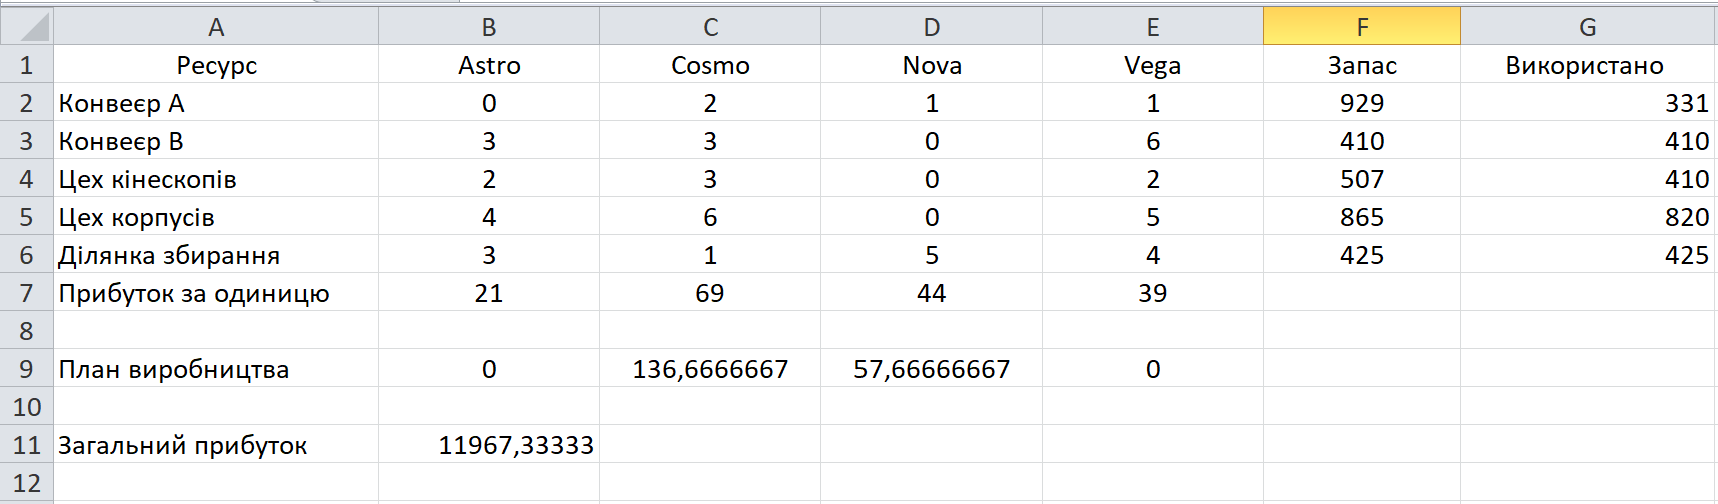
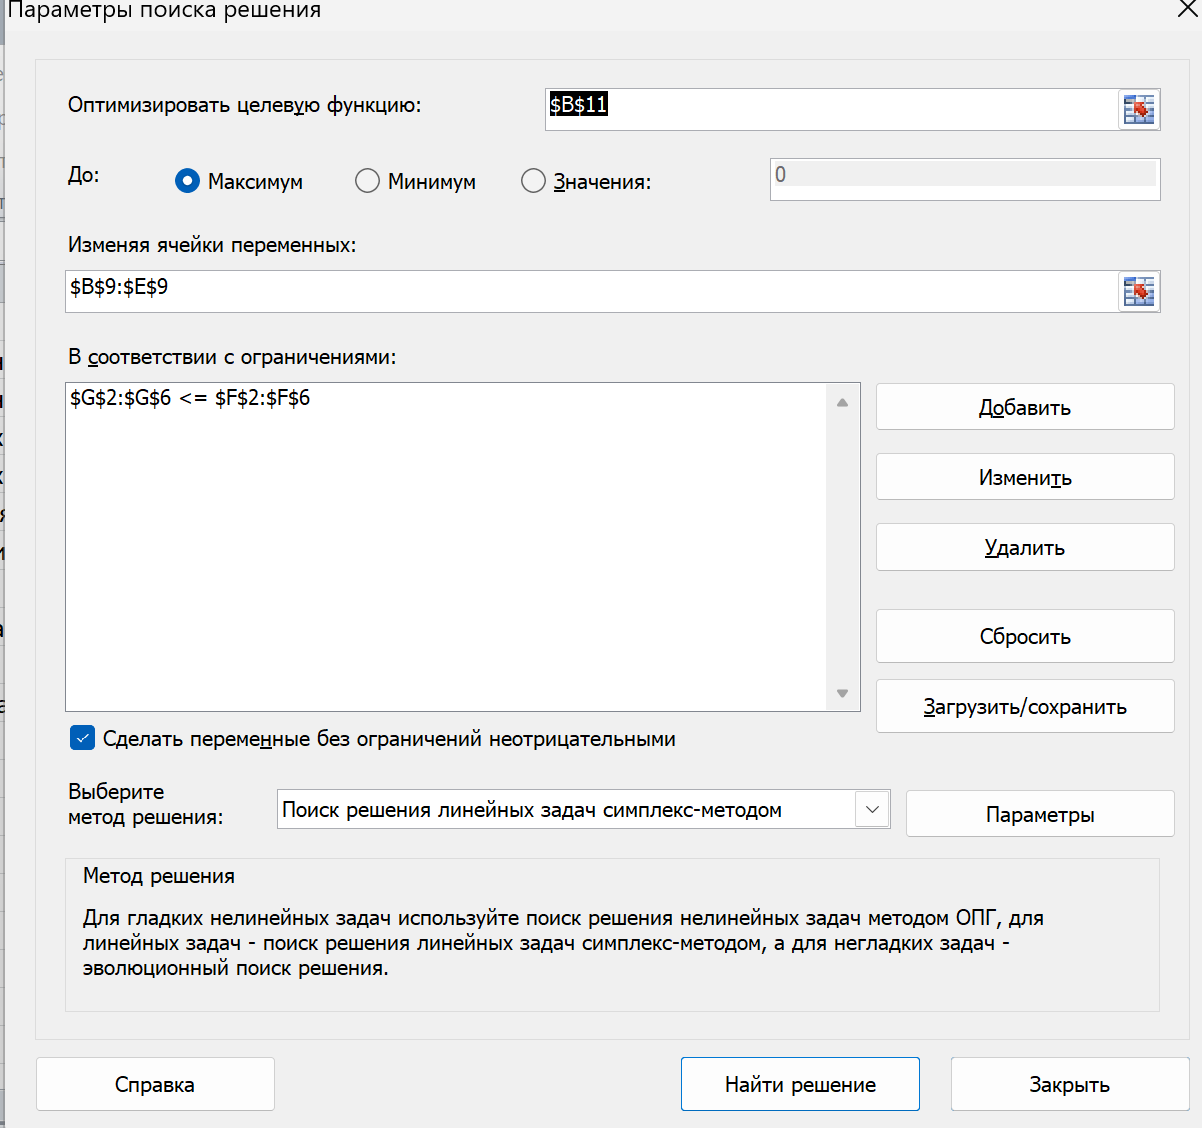
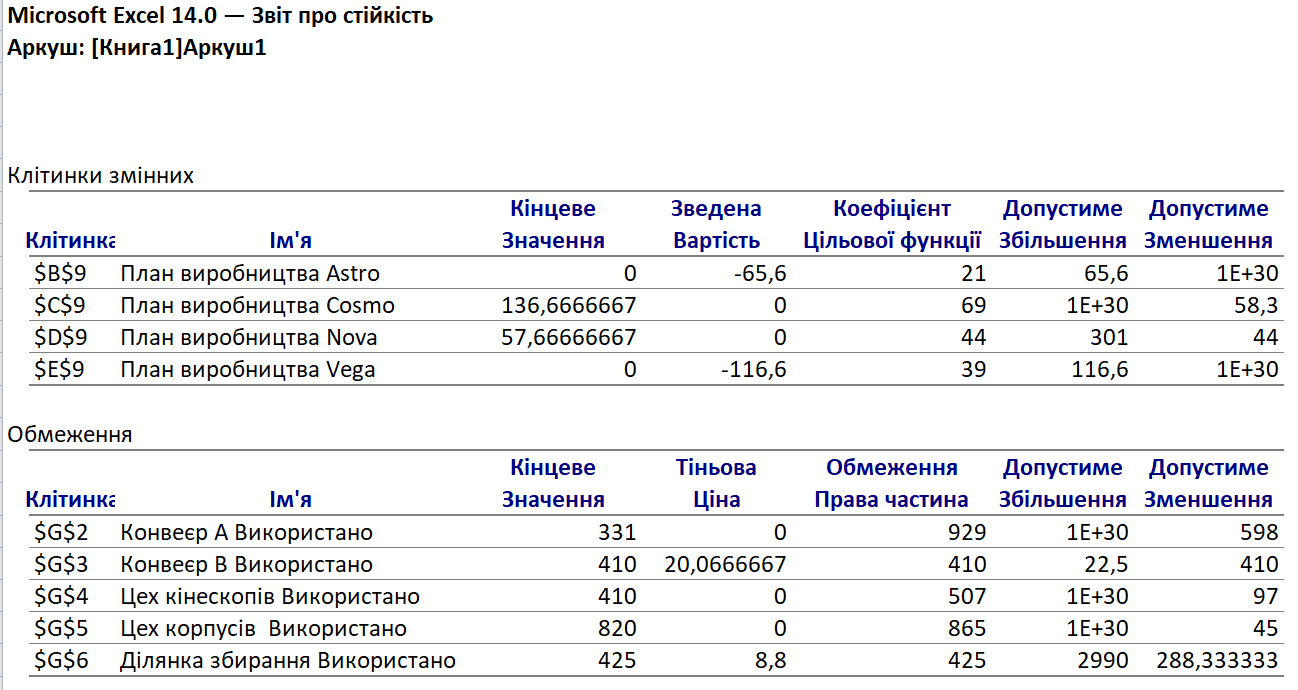

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.



In [5]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [0, 136.6666667, 57.6666667, 0]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 11967.33333            # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 136.6666667, 57.6666667, 0] | прибуток 11967.33333


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [13]:
# ВАШ КОД
from scipy.optimize import linprog
c = [-21, -69, -44, -39]
A_ub = [
    [0, 2, 1, 1],  
    [3, 3, 0, 6],  
    [2, 3, 0, 2],  
    [4, 6, 0, 5],  
    [3, 1, 5, 4]   
]

b_ub = [929, 410, 507, 865, 425]

bounds = [(0, None)] * 4
result = linprog(c, A_ub = A_ub, b_ub = b_ub, bounds=bounds , method="highs" )
print(result.success)
print(result.x)
print(-result.fun)

план = result.x
прибуток = -result.fun

True
[  0.         136.66666667  57.66666667   0.        ]
11967.333333333334


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [14]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
|Конвеєр А | 331 | 0 | 929 | 1E+30 | 598 |
|Конвеєр Б | 410 | 20,0667 | 410 | 22,5 | 410 |
|Цех кінескопів | 410 | 0 | 507 | 1E+30 | 97 |
|Цех корпусів | 820 | 0 | 865 | 1E+30 | 45 |
|Ділянка збирання| 425 | 8,8 | 425 | 2990 | 288,3333 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**
Ресурс конвеєра Б та ресурс Ділянки збирання є в дефіциті ,окскільки кінцеве значення - це скільки ресурсів було застосовано, а права частина - це загальна кількість ресурсів ,отже це означає що ми використовуємо всі наші ресурси(години) .Надлишковими є конвеєр А, цех кінескопів та цех корпусів.Визначила я це за аналогічною анологією лише між ними різниця щоб кінцеве значення було менше ніж права частина.


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Astro | 0 | -65,6 | 21 | 65,6 | 1E+30 |
| Cosmo | 136,6667 | 0 | 69 | 1E+30 | 58,3 |
| Nova | 57,6667 | 0 | 44 | 301 | 44 |
| Vega | 0 | -116,6 | 39 | 116,6 | 1E+30 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

У моєму варіанті таких вироби два - це Astro nа Vega. Прибуток мусів би зрости у першому виробі на - 65,6 ,а у іншому на 116,6 .Це випливає з зведеної вартості ,і у допустимому збільшенні покано ,що якщо ті значення змінити то вони увійдуть в наш оптимальний план.

---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [15]:
# ВАШ КОД

from scipy.optimize import linprog

c = [-21, -69, -44, -39]

A_ub = [
    [0, 2, 1, 1],
    [3, 3, 0, 6],
    [2, 3, 0, 2],
    [4, 6, 0, 5],
    [3, 1, 5, 4]
]

b_ub = [929, 410, 507, 865, 425]

original = linprog(
    c, A_ub=A_ub, b_ub=b_ub,
    bounds=(0, None), method="highs"
)

new_b = b_ub.copy()
new_b[1] += 1

updated = linprog(
    c, A_ub=A_ub, b_ub=new_b,
    bounds=(0, None), method="highs"
)

old_profit = -original.fun
new_profit = -updated.fun

print("Початковий прибуток:", round(old_profit, 4))
print("Новий прибуток:", round(new_profit, 4))
print("Приріст прибутку:", round(new_profit - old_profit, 4))
print("Тіньова ціна зі звіту:", 20.0667)



Початковий прибуток: 11967.3333
Новий прибуток: 11987.4
Приріст прибутку: 20.0667
Тіньова ціна зі звіту: 20.0667


**Відповідь 5.1:***приріст прибутку збігається з тіньовою ціною зі звіту. Отже, експеримент підтверджує, що додаткова година роботи Конвеєра Б збільшує максимальний прибуток приблизно на 20,0667.

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

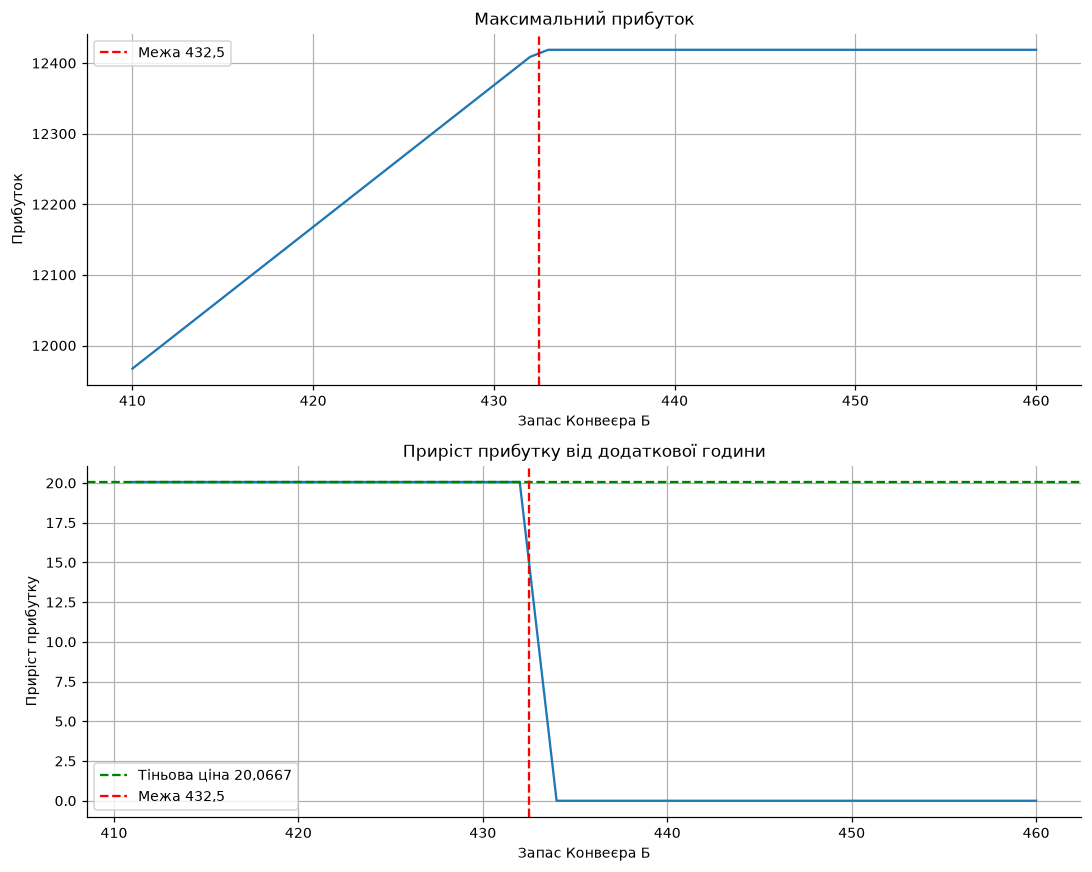

In [16]:
# ВАШ КОД

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

c = [-21, -69, -44, -39]

A_ub = [
    [0, 2, 1, 1],
    [3, 3, 0, 6],
    [2, 3, 0, 2],
    [4, 6, 0, 5],
    [3, 1, 5, 4]
]

b_ub = [929, 410, 507, 865, 425]

stocks = np.arange(410, 461, 1)
profits = []

for stock in stocks:
    new_b = b_ub.copy()
    new_b[1] = stock

    result = linprog(
        c,
        A_ub=A_ub,
        b_ub=new_b,
        bounds=(0, None),
        method="highs"
    )

    profits.append(-result.fun)

increases = np.diff(profits)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(stocks, profits)
plt.axvline(432.5, color="red", linestyle="--", label="Межа 432,5")
plt.title("Максимальний прибуток")
plt.xlabel("Запас Конвеєра Б")
plt.ylabel("Прибуток")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(stocks[1:], increases)
plt.axhline(20.0667, color="green", linestyle="--", label="Тіньова ціна 20,0667")
plt.axvline(432.5, color="red", linestyle="--", label="Межа 432,5")
plt.title("Приріст прибутку від додаткової години")
plt.xlabel("Запас Конвеєра Б")
plt.ylabel("Приріст прибутку")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


**Відповідь 5.2:** *(на скільки одиниць можна збільшити запас, доки тіньова ціна не зміниться;
чи збігається знайдена межа з «допустимим збільшенням» зі звіту Excel)*

Для дослідження я обрала конвеєр Б. Початковий запас якого становить 410 ,а тіньова ціна - 20,0667.За результатами експерименту в Python встановлено, що запас Конвеєра Б можна збільшити на 22,5 години, тобто до 432,5 години, і протягом цього діапазону тіньова ціна залишатиметься незмінною.Після перевищення цієї межі тіньова ціна стає нульовою, оскільки подальше збільшення запасу Конвеєра Б уже не підвищує максимальний прибуток.

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [17]:
# ВАШ КОД

from scipy.optimize import linprog

c = [-21, -69, -44, -39]

A_ub = [
    [0, 2, 1, 1],
    [3, 3, 0, 6],
    [2, 3, 0, 2],
    [4, 6, 0, 5],
    [3, 1, 5, 4]
]

b_ub = [929, 410, 507, 865, 425]

price = 16.2
max_offer = 44

shadow_price = 20.0667
allowable_increase = 22.5

if price < shadow_price:
    print("Купувати вигідно")
    purchase = min(max_offer, allowable_increase)
else:
    print("Купувати невигідно")
    purchase = 0

print("Кількість годин для закупівлі:", purchase)

original = linprog(
    c,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=(0, None),
    method="highs"
)

new_b = b_ub.copy()
new_b[1] += purchase

updated = linprog(
    c,
    A_ub=A_ub,
    b_ub=new_b,
    bounds=(0, None),
    method="highs"
)

old_profit = -original.fun
new_profit = -updated.fun

extra_profit = new_profit - old_profit
purchase_cost = purchase * price
net_gain = extra_profit - purchase_cost

print("Початковий прибуток:", round(old_profit, 4))
print("Новий прибуток:", round(new_profit, 4))
print("Приріст прибутку:", round(extra_profit, 4))
print("Вартість закупівлі:", round(purchase_cost, 4))
print("Очікуваний виграш:", round(purchase * (shadow_price - price), 4))
print("Чистий виграш після перевірки:", round(net_gain, 4))


Купувати вигідно
Кількість годин для закупівлі: 22.5
Початковий прибуток: 11967.3333
Новий прибуток: 12418.8333
Приріст прибутку: 451.5
Вартість закупівлі: 364.5
Очікуваний виграш: 87.0008
Чистий виграш після перевірки: 87.0


**Відповідь 6.1:**

* Брати чи ні і чому: Брати,окскільки я порахувала , що якщо за одну додаткову годину ми отримуватимо 20,7 ,а за одну годину будемо платити 16,2 то ми в плюсі на 4,5.
* Скільки одиниць має сенс купити і чому не більше: Є сенс куплти 22,5 годин оскільки після них це вже не буде збільшувати наш максимальний прибуток.
* Очікуваний виграш:87 одиниць чистого прибутку
* Перевірка прямим розв'язанням дала: Початковий прибуток 11967,3333, новий прибуток 12418,8333. Приріст становить 451,5, витрати на закупівлю — 364,5, чистий виграш — 87. Отже, розрахунки підтверджено.


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [18]:
# ВАШ КОД

from scipy.optimize import linprog
import numpy as np

c = [-21, -69, -44, -39]

A_ub = np.array([
    [0, 2, 1, 1],
    [3, 3, 0, 6],
    [2, 3, 0, 2],
    [4, 6, 0, 5],
    [3, 1, 5, 4]
])

b_ub = np.array([929, 410, 507, 865, 425])

result = linprog(
    c,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=(0, None),
    method="highs"
)

ненульових = np.sum(result.x > 1e-7)

used = A_ub @ result.x
звязних = np.sum(np.isclose(used, b_ub, atol=1e-7))

print("Ненульових змінних:", ненульових)
print("Зв'язаних обмежень:", звязних)



Ненульових змінних: 2
Зв'язаних обмежень: 2


In [19]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** *(чи збіглися числа; що означала б розбіжність на практиці)* Так,числа збіглись. На практиці це означає, що кількість видів продукції, які виробляються, не збігається з кількістю ресурсів, які використовуються повністю.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [20]:
# ВАШ КОД

import numpy as np
from scipy.optimize import linprog

c = np.array([-21, -69, -44, -39])

A_ub = np.array([
    [0, 2, 1, 1],
    [3, 3, 0, 6],
    [2, 3, 0, 2],
    [4, 6, 0, 5],
    [3, 1, 5, 4]
])

b_ub = np.array([929, 410, 507, 865, 425])

normal = linprog(
    c, A_ub=A_ub, b_ub=b_ub,
    bounds=(0, None), method="highs"
)

rounded = np.rint(normal.x).astype(int)

rounded_used = A_ub @ rounded
rounded_valid = np.all(rounded_used <= b_ub)

integer = linprog(
    c, A_ub=A_ub, b_ub=b_ub,
    bounds=(0, None),
    integrality=1,
    method="highs"
)

print("Без умови цілочисельності:")
print("План:", np.round(normal.x, 4))
print("Прибуток:", round(-normal.fun, 4))

print("\nОкруглений план:")
print("План:", rounded)
print("Прибуток:", -c @ rounded)
print("Допустимий:", rounded_valid)

print("\nЦілочисельний оптимум:")
print("План:", np.rint(integer.x).astype(int))
print("Прибуток:", round(-integer.fun, 4))
print("Допустимий:", np.all(A_ub @ integer.x <= b_ub + 1e-7))


Без умови цілочисельності:
План: [  0.     136.6667  57.6667   0.    ]
Прибуток: 11967.3333

Округлений план:
План: [  0 137  58   0]
Прибуток: 12005
Допустимий: False

Цілочисельний оптимум:
План: [  0 136  57   0]
Прибуток: 11892.0
Допустимий: True


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | 0,  136.7,  57.7,  0 | 11967.3 | Так |
| округлений | 0 137 58 0 |12005  | Ні |
| цілочисельний оптимум | 0 136 57 0 | 11892 | Так |

**Висновок:** *(чи можна округлювати і чому)*


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [21]:
# ВАШ КОД — впишіть свої дані
постачальники = ['Апостолове', 'Ніжин', 'Дрогобич']            # напр. ['Шостка', 'Енергодар', 'Вінниця']
споживачі     = ['Самбір', 'Острог', 'Львів', 'Одеса']            # напр. ['Тернопіль', 'Афанасіївка', 'Рівне', 'Апостолове']
D = np.array([
    [1080, 780, 996, 397],
    [780, 480, 695, 629],
    [32, 310, 83, 872]])             # матриця відстаней 3 x 4, км
запас = np.array([20, 30, 25])                # 3 числа
попит = np.array([15, 20, 25, 15])                   # 4 числа

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Самбір,Острог,Львів,Одеса
Апостолове,1080,780,996,397
Ніжин,780,480,695,629
Дрогобич,32,310,83,872


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [22]:
# ВАШ КОД — розв'язок 1

from scipy.optimize import linprog
import numpy as np
import pandas as pd

m, n = D.shape

c = D.flatten()

A_eq = []
b_eq = []

for i in range(m):
    row = np.zeros(m * n)

    for j in range(n):
        row[i * n + j] = 1

    A_eq.append(row)
    b_eq.append(запас[i])

for j in range(n):
    row = np.zeros(m * n)

    for i in range(m):
        row[i * n + j] = 1

    A_eq.append(row)
    b_eq.append(попит[j])

result = linprog(
    c,
    A_eq=np.array(A_eq),
    b_eq=np.array(b_eq),
    bounds=(0, None),
    method="highs"
)

if result.success:
    plan = result.x.reshape(m, n)

    print("Оптимальний план перевезень:")
    display(pd.DataFrame(
        plan,
        index=постачальники,
        columns=споживачі
    ))

    print("Мінімальна сумарна вартість:", result.fun)

    print("Тіньові ціни:")
    for name, price in zip(
        постачальники + споживачі,
        result.eqlin.marginals
    ):
        print(name, ":", round(price, 2))
else:
    print(result.message)



Оптимальний план перевезень:


,Самбір,Острог,Львів,Одеса
Апостолове,0.0,5.0,0.0,15.0
Ніжин,0.0,15.0,15.0,0.0
Дрогобич,15.0,0.0,10.0,0.0


Мінімальна сумарна вартість: 28790.0
Тіньові ціни:
Апостолове : 780.0
Ніжин : 480.0
Дрогобич : -132.0
Самбір : 164.0
Острог : -0.0
Львів : 215.0
Одеса : -383.0


In [30]:
%pip install "pulp==2.9.0" --force-reinstall

  Using cached PuLP-2.9.0-py3-none-any.whl.metadata (5.4 kB)
Using cached PuLP-2.9.0-py3-none-any.whl (17.7 MB)
  Attempting uninstall: pulp
    Found existing installation: PuLP 2.9.0
    Uninstalling PuLP-2.9.0:
      Successfully uninstalled PuLP-2.9.0
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import pulp
print(pulp.__version__)

4.0.0


In [28]:
# ВАШ КОД — розв'язок 2

import pulp
import numpy as np
import pandas as pd

model = pulp.LpProblem("Transport", pulp.LpMinimize)

m, n = D.shape

x = [
    [pulp.LpVariable(f"x_{i}_{j}", lowBound=0) for j in range(n)]
    for i in range(m)
]

model += pulp.lpSum(
    D[i, j] * x[i][j]
    for i in range(m)
    for j in range(n)
)

for i in range(m):
    model += (
        pulp.lpSum(x[i][j] for j in range(n)) == int(запас[i]),
        f"Supply_{i}"
    )

for j in range(n):
    model += (
        pulp.lpSum(x[i][j] for i in range(m)) == int(попит[j]),
        f"Demand_{j}"
    )

model.solve(pulp.PULP_CBC_CMD(msg=False))

print("Статус:", pulp.LpStatus[model.status])

if pulp.LpStatus[model.status] == "Optimal":
    plan = np.array([
        [pulp.value(x[i][j]) for j in range(n)]
        for i in range(m)
    ])

    print("\nОптимальний план:")
    display(pd.DataFrame(
        plan,
        index=постачальники,
        columns=споживачі
    ))

    print("Мінімальна сумарна вартість:",
          pulp.value(model.objective))

    print("\nТіньові ціни:")
    for name, constraint in model.constraints.items():
        print(name, ":", constraint.pi)

TypeError: LpVariable.__init__() got an unexpected keyword argument 'lowBound'

### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [ ]:
# ВАШ КОД — порівняння


**Відповідь 10.2:**

* Вартість у двох розв'язувачів:
* Тіньові ціни збіглися чи ні:
* Яку закономірність ви побачили в різниці:
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом:


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [ ]:
# ВАШ КОД


**Відповідь 11.1:**

* Ненульових перевезень:
* Зв'язних обмежень:
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження:
* На скільки ненульових перевезень менше і чому саме на стільки:


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

In [ ]:
# ВАШ КОД


**Висновок:** *(одне речення про те, що видно на теплових картах)*

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [ ]:
ІНСТРУМЕНТИ_ШІ = ''     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          '',
    'етап 2, побудова моделі в Excel':      '',
    'етап 3, код на Python':                '',
    'етапи 4–5, читання та перевірка звіту': '',
    'етап 6, рішення про закупівлю':        '',
    'етапи 7–8, перевірка та цілочисельність': '',
    'етапи 9–11, транспортна задача':       '',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = ''

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = False

In [ ]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

---
# Крок 13. Фінальна самоперевірка

In [ ]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')